# Akar-akar persamaan

Akar-akar persamaan adalah posisi-posisi khusus dalam sebuah kurva yang dapat digunakan untuk memahami bentuknya berkaitan dengan cara kurva tersebut didapat. Lajimnya, bentuk kurva ditentukan oleh fungsi yang menggambarkannya yang biasanya terdiri dari variabel bebas dan variablel terikat. Variabel bebas menentukan nilai dari variabel terikat, yang dalam ekspresi matematika dituliskan,
$$
y=f(x)
$$
Dalam persamaan diatas $y$ adalah variabel terikat, sedangkan $x$ adalah variabel bebas. Banyaknya variabel bebas dapat lebih dari satu bergantung dari dimensi fungsi, Namun untuk sebuah kurva kita bekerja hanya dengan satu variabel bebas.

Di dalam pekerjaan analisis data, didapati kasus ketika justru nilai variabel bebas yang ingin diketahui pada nilai $y$ tertentu, misalnya pada $y=0$. Misalnya ketika data $y_i$ diketahui melalui pengukuran. Jika fungsi yang dihadapi memiliki bentuk yang tertentu, lokasi $x$ dapat diketahui melalui faktorisasi. Misalnya sebuah fungsi kuadrat memiliki bentuk,
$$x^2 - 2x -8 = 0$$
maka melalui faktorisasi dapat diketahui nilai-nilai $x$ ketika $y=0$,
$$
\begin{aligned}
(x+2)(x-4) = 0 \\
x_1 = -2; ~~~x_2 = 4
\end{aligned}
$$
Sehingga dapat ditentukan bahwa nilai $y=0$ akan di dapat ketika $x=-2$ dan $x=4$. Nilai-nilai $x_1$ dan $x_2$ adalah akar-akar dari persamaan $x^2 - 2x -8 = 0$. Banyaknya akar-akar dari sebuah persamaan, maksimal sama dengan orde persamaan tersebut.

Berikut adalah penampilan fungsi contoh diatas menggunakan program.

---

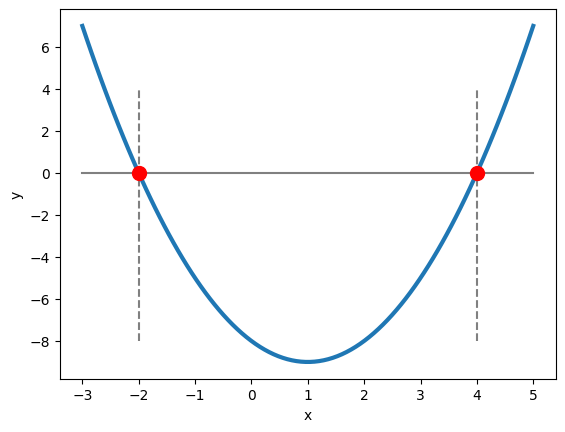

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x=np.linspace(-3,5,100)
y=x**2-2*x-8
x1=-2
x2=4

plt.plot(x,y, '-', linewidth=3)
plt.plot([x[0],x[-1]], [0,0], color='gray')
plt.plot([-2,-2], [-8,4], '--', color='gray')
plt.plot([4,4], [-8,4], '--', color='gray')
plt.plot([x1, x2], [0,0], 'o', markersize=10, color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


## Pencarian akar persamaan pada data diskrit

Data hasil pengukuran seringkali menyimpang dari fungsi yang dikehendaki dan bersifat diskrit. Perhatikan gambar dibawah. Jika data-data ketinggian dari tebing di pinggir pantai diketahui, maka pada posisi berapakah permukaan laut pada tebing tersebut? Jawaban dari pertanyaan ini tidak dapat diberikan melalui perhitungan faktorisasi fungsi. Akan tetapi dapat diberikan dengan menggunakan algoritma pencarian akar persamaan dengan data numerik.

![ikan paus](rootwhale.png)

Jika data-data dari fungsi yang tidak diketahui itu cukup rapat, maka algoritma pencarian akan dapat langsung diterapkan pada data. Jika tidak demikian, maka perlu digunakan fungsi interpolasi atau ekstrapolasi sehingga proses pencarian akar persamaan dapat memberikan hasil yang akurat, karena bekerja dengan fungsi kontinyu.


### Pencarian inkremental

Metode pencarian akar ini adalah yang paling mudah. Pertama, cari nilai awal di sekitar nilai akar, kemudian mengikuti kurva langkah demi langkah hingga nilai dari fungsi berubah tanda. Tentu saja pengetahuan apriori terhadap lokasi akar harus diperkirakan dengan baik, jika tidak akar tidak dapat ditemukan.

In [6]:
# deklarasi fungsi pencarian akar persamaan
# parameter: 
# f <-- fungsi
# a dan b <-- rentang pencarian
# dx <-- langkah penambahan variabel bebas x

def cariAkar(f,a,b,dx):
    x1=a
    f1=f(a)
    x2=a+dx
    f2=f(x2)
    nitr=0
    
    while np.sign(f1) == np.sign(f2):
        if x1 >= b: return None
        x1=x2
        f1=f2
        x2=x1+dx
        f2=f(x2)
        nitr+=1
    else:
        return (x1+x2)/2.0, nitr

Untuk mencoba algoritma ini, kita cari akar-akar dari $x^3-10x^2+5=0$ dalam interval $x=(0.2, 1.0)$, dengan menggunakan lebar langkah $\Delta x=0.0001$. Untuk itu pertama, definisikan fungsi yang dapat memberikan nilai $y$ pada harga-harga $x$.

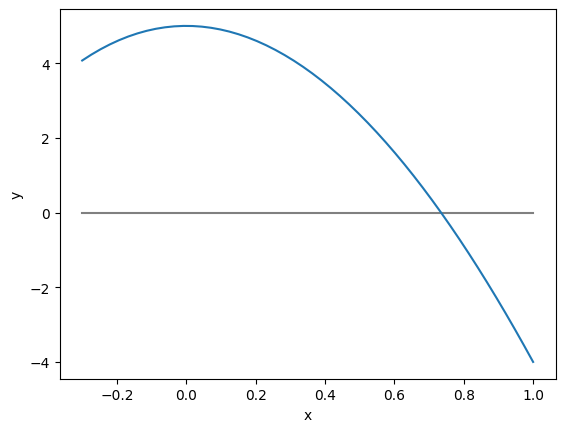

In [7]:
# definisikan fungsi
# y = x^3 - 10 x^2 + 5

def f(x):
  return x**3 - 10.0*x**2 + 5.0

# plot fungsi untuk melihat bentuk kurva
xx=np.linspace(-0.3,1.0,50)
plt.plot([xx[0],xx[-1]],[0,0], '-', color='gray')
plt.plot(xx,f(xx))
plt.xlabel('x')
plt.ylabel('y')
plt.show()


Perhatikan bahwa fungsi memiliki nilai maksimum, sehingga pencarian akar-akar akan sangat dipengaruhi oleh titik tebakan pertama atau rentang daerah pencarian akar.
Lakukan pencarian akar pada daerah yang sudah diperkirakan. Dalam aplikasi metode ini, memperhatikan bentuk kurva sebelum algoritma dijalankan sangat penting.

x = 0.75000 iterasi: 5
x = 0.73500 iterasi: 53
x = 0.73450 iterasi: 534
x = 0.73465 iterasi: 5346


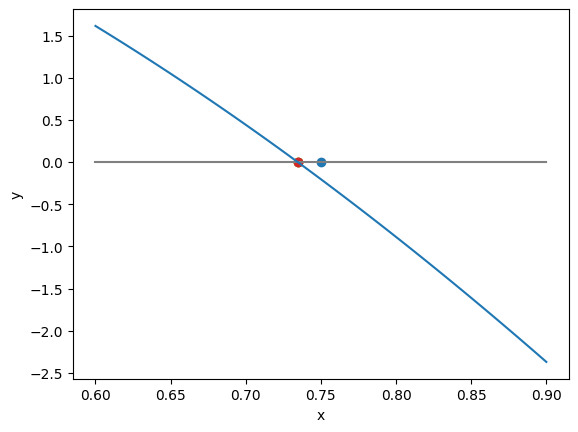

In [8]:
# rentang daerah pencarian akar
x1=0.2
x2=1.0

xx=np.linspace(0.6,0.9,50)
plt.plot([xx[0],xx[-1]],[0,0], '-', color='gray')
plt.plot(xx,f(xx))

for dx in [0.1, 0.01, 0.001, 0.0001]:
    x,nitr = cariAkar(f,x1,x2,dx)
    print(f'x = {x:6.5f} iterasi: {nitr}')
    plt.scatter(x,0)

plt.xlabel('x')
plt.ylabel('y')
plt.show()



### Pencarian inkremental dengan penghalusan

Dengan menggunakan pencarian inkremental ketelitian hasil sangat sensitif terhadap ukuran langkah, $\Delta x$. Dapat dilihat dari demonstrasi diatas, bahwa semakin kecil langkah yang digunakan, semakin teliti pula hasil yang didapat. Akan tetapi jumlah iterasi yang diperlukan menjadi sangat besar. Dalam contoh diatas akurasi  yang baik didapat dengan 1000 kali lebih banyak perhitungan. Untuk mengatasi masalah ini dapat dilakukan penghalusan, yang mana algoritma dilakukan berulang dengan rentang daerah pencarian yang diperkecil serta $\Delta x$ bergantung pada rentang tersebut, yaitu diambil sebagai faktor dari titik tengah rentang awal yang diberikan.

x = 0.7347656250; iterasi = 5


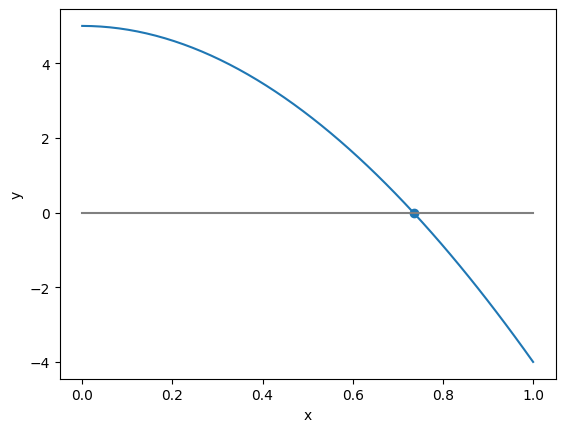

In [9]:
# prosedur sama akan tetapi mengembalikan batas baru
def cariAkarB(f,a,b,dx):
    x1=a
    f1=f(a)
    x2=a+dx
    f2=f(x2)
    nitr=0
    
    while np.sign(f1) == np.sign(f2):
        if x1 >= b: return None
        x1=x2
        f1=f2
        x2=x1+dx
        f2=f(x2)
        nitr+=1
    else:
        return x1,x2, nitr

# Fungsi didefinisikan pada sel sebelumnya
x1=0.2
x2=1.0
nitr=0
for i in range(10):
    dx=(x2-x1)/2
    x1,x2,ni=cariAkarB(f,x1,x2,dx)
    nitr+=ni

x=(x1+x2)/2
print(f'x = {x:6.10f}; iterasi = {nitr}')

xx=np.linspace(0,1,50)
plt.plot(xx,f(xx))
plt.plot([xx[0],xx[-1]],[0,0], '-', color='gray')
plt.scatter(x,0)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

### Bisection Method

Metode _Bisection_ mirif dengan metode inkremental dengan batas yang diperhalus. Namun kita dapat menentukan jumlah iterasi sesuai dengan ketelitian yang diinginkan. Toleransi yang diinginkan, $\epsilon$, tercapai jika $$|x_1 - x_2|\leq \epsilon$$ 
Maka banyaknya pengulangan, $n$, yang dilakukan adalah,
$$n=\frac{\ln(\Delta x/\epsilon)}{\ln 2}$$

Berikut algoritma pencarian akar dengan metode _bisection_, yang mana batas toleransi digunakan sebagai akhir dari pengulangan perhitungan.

In [10]:
def bisect(f, x1, x2, tol=1.0e-9):
    nitr=0
    f1 = f(x1)
    f2 = f(x2)
    if f1 == 0.0: return x1,nitr
    if f2 == 0.0: return x2,nitr    
    if np.sign(f1) == np.sign(f2):
        print('akar tidak berada pada rentang')
        return None,nitr

    n = int(np.ceil(np.log(abs(x2 - x1)/tol)/np.log(2.0)))
    
    for i in range(n):
        x3 = (x1 + x2)/2
        f3 = f(x3)
        if f3 == 0.0: return x3,nitr
        if np.sign(f2)!= np.sign(f3): x1 = x3; f1 = f3
        else: 
            x2 = x3
            f2 = f3
        nitr+=1

    return (x1 + x2)/2.0, nitr

Metode bisection digunakan dengan cara sama seperti metode inkremental, akan tetapi toleransi ditentukan sebagai parameter. Harus diingat bahwa lokasi akar harus berada diantara rentang awal yang diberikan.

x = 0.7345886230; iterasi=14


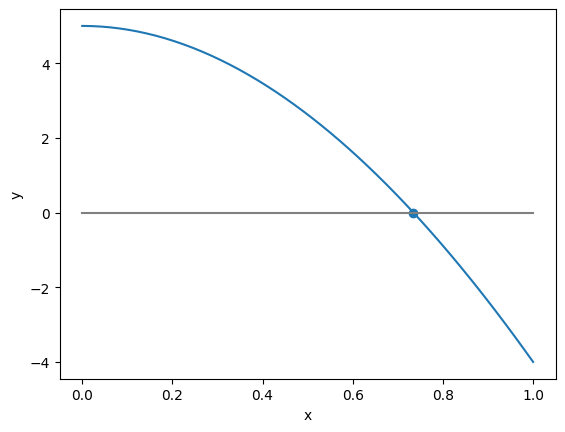

In [11]:
x,ni=bisect(f,0.0,1.0,tol=1.0e-4)
print(f'x = {x:6.10f}; iterasi={ni}')
xx=np.linspace(0,1,50)
plt.plot(xx,f(xx))
plt.plot([xx[0],xx[-1]],[0,0], '-', color='gray')
plt.scatter(x,0)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Metode pencarian akar dengan interpolasi linear

Memberikan tebakan awal titik-titik yang melingkupi akar persamaan menjadi tidak optimal ketika harus dilakukan secara visual. Dalam data yang banyak, seringkali kita membutuhkan cara yang lebih otomatis tanpa harus ada intervensi manusia terlalu banyak. Salah satu solusinya adalah dengan menarik persamaan garis dari dua titik sembarang kemudian mengamati posisi koordinat dari garis tersebut yang memotong sumbu-$y$. Hal ini mudah dilakukan menggunakan persamaan garis. Jika titik tebakan adalah $x_1$ dan $x_2$, titik tebakan berikutnya didapat sebagai berikut,
$$
x_3 = x_2 - y_2 \frac{x_2-x_1}{y_2-y_1}
$$


Ada dua metode yang menggunakan teknik interpolasi linear, yaitu,

1. algoritma _false-position_ menggunakan dua koordinat tebakan yang melingkupi akar persamaan, sehingga titik-titik tebakan berikutnya $x_3$ dan salah satu tebakan sebelumnya dengan tanda berbeda dengan 
2. algoritma _secant_ menggunakan dua titik untuk mengambil garis potong terhadap kurva untuk menentukan titik tebakan berikutnya, dan titik tebakan berikutnya diganti dengan titik yang baru secara progresif.

Berikut adalah implementasi metode pencarian akar persamaan dengan algoritma _secant_.

---

x = 0.734604; iterasi = 4


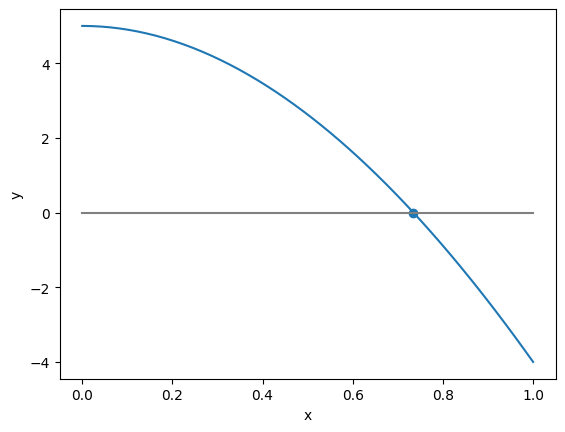

In [12]:
def secant_method(f, x0, x1, tol=1e-6, max_iter=100):
    nitr = 0
    for i in range(max_iter):
        x2 = x1 - f(x1) * (x1 - x0) / (f(x1)-f(x0))
        if abs(f(x2)) < tol: return x2,nitr
        x0, x1 = x1, x2
        nitr+=1

    print('melebihi iterasi maksimum')
    return x2,nitr

x,nitr = secant_method(f, x0=0.2, x1=1)
print(f"x = {x:.6f}; iterasi = {nitr}")
plt.plot(xx,f(xx))
plt.plot([xx[0],xx[-1]],[0,0], '-', color='gray')
plt.scatter(x,0)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Jika sebuah fungsi diketahui dengan baik bentuk turunannya, maka akar-akar persamaan dapat dicari dengan memberikan satu titik tebakan saja. Jika $y'$ adalah turunan pertama daru $y$, maka titik tebakan berikutnya dihitung dengan,
$$
x_{t+1} = x_t - \frac{y_i}{y'_i}
$$
Dalam persamaan ini $t$ adalah urutan pengulangan (iterasi) dalam prosedur pencarian akar, $t+1$ adalah iterasi berikutnya. Algoritma ini dikenal dengan algoritma Newton-Rhapson.

---

In [13]:
def newton_raphson(f, df, x0, tol=1e-7, max_iter=100):
    xn = x0
    nitr=0
    for i in range(max_iter):
        fxn = f(xn)
        dfxn = df(xn)        
        xn_next = xn - fxn / dfxn
        if abs(xn_next - xn) < tol:
            return xn_next,nitr
        xn = xn_next
        nitr+=1

    print("maksimum iterasi terlampaui")
    return xn,nitr


x= 0.734604; iterasi=5


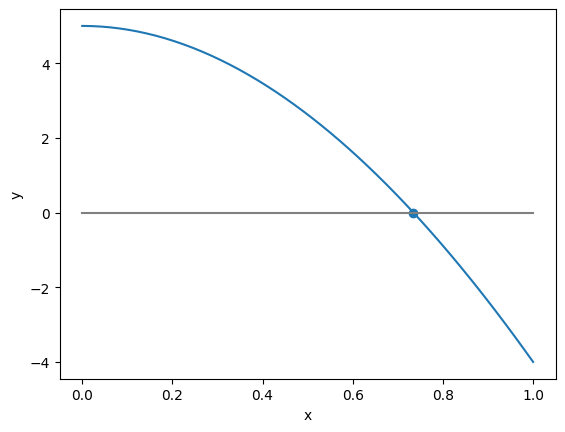

In [15]:
# definisikan fungsi
# y = x^3 - 10 x^2 + 5

def f(x):
  return x**3 - 10.0*x**2 + 5.0

# turunan fungsi y:
# y' = 3x^2 - 20x

def df(x):
    return 3*x**2 - 20*x

x,nitr = newton_raphson(f, df, x0=0.2)
print(f"x= {x:.6f}; iterasi={nitr}")

plt.plot(xx,f(xx))
plt.plot([xx[0],xx[-1]],[0,0], '-', color='gray')
plt.scatter(x,0)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Penyelesaian akar-akar dari sistem persamaan

Pencarian akar-akar persamaan tidak hanya dilakukan pada persamaan dengan satu variable, akan tetapi dapat pula dikerjakan untuk persamaan dengan banyak variabel, atau sering disebut dengan fungsi multi dimensi. Dalam kasus ini persamaan dituliskan dalam notasi vektor sebagai berikut, 
$$
{\bf f}({\bf x})=0
$$
Pada sistem persamaan ini, $\bf f=[f_1, f_2, ..., f_n]$ adalah fungsi vektor dan ${\bf x}=[x_1, x_2, ..., x_n]$ adalah variabel vektor. Catat bahwa dalam deskripsi ini indeks dari variabel $x$ bukan representasi dari akar-akar melainkan menunjukkan dimensi dari variabel.

Untuk menyelesaikan akar-akar dari sistem persamaan digunakan metode Newton-Rapson. Dari ekspansi Taylor didapat hubungan,
$$
f_i({\bf x+\Delta x}) =  f_i({\bf x}) + \sum_{j=1}^n \frac{\partial f_i}{\partial x_j} \Delta x_j + O(\Delta x^2)
$$
Suku $O(\Delta x^2)$ menyatakan suku-suku orde yang lebih dari satu. Suku-suku ini dibuang dan diperlakukan sebagak nilai kesalahan dari algoritma, sehingga didapatkan,
$$
\bf
f(x+\Delta x) = f(x) + J(x)\Delta x
$$
$\bf J(x)$ adalah sebuah matriks yang berisi turunan parsial dari fungsi dengan elemen-elemen,
$$J_{ij}=\frac{\partial f_i}{\partial x_j}$$

Matriks ini disebut dengan matriks _Jacobian_ yang memiliki bentuk,
$$
{\bf J(x)} = \left[\begin{matrix}
\frac{\partial f_1}{\partial x_1} & 
\frac{\partial f_1}{\partial x_2} & ... & 
\frac{\partial f_1}{\partial x_n} \\
\frac{\partial f_2}{\partial x_1} & 
\frac{\partial f_2}{\partial x_2} & ... & 
\frac{\partial f_2}{\partial x_n} \\
\vdots & \vdots & ... & \vdots \\
\frac{\partial f_m}{\partial x_1} & 
\frac{\partial f_m}{\partial x_2} & ... & 
\frac{\partial f_m}{\partial x_n} \\
\end{matrix}\right]
$$

Dengan demikian sistem persamaan dapat dipandang sebagai persamaan linear. Turunan parsial dari fungsi dapat diambil dengan menggunakan persamaan beda hingga, sebagai berikut,
$$\frac{\partial f_i}{\partial x_j} \approx 
\frac{f_i({\bf x} + \hat{\bf e}h) - f_i({\bf x})}{h}
$$
Dalam persamaan aproksimasi diatas $\hat{\bf e}$ adalah vektor satuan dalam dimensi $n$, dan $h$ merupakan lebar diskretisasi dalam pengambilan aproksimasi turunan.

Setelah matriks _Jacobian_, $\bf J(x)$, dibangun penyelesaian akar-akar persamaan dapat dilakukan dengan menghitung penambahan nilai titik tebakan pada iterasi selanjutnya.

Prosedur pengulangan pencarian akar sistem persamaan dilakukan sebagai berikut,

1. Berikan nilai tebakan untuk vektor $\bf x$. Ini berarti kita harus memberikan nilai awal sebanyak $n$ tebakan.
2. Hitung turunan parsial terhadap semua variabel $x_i$ untuk membangun $\bf J(x)$
3. Selesaikan persamaan linear _Jacobian_ menggunakan teknik eliminasi untuk mendapatkan $\bf \Delta x$, yaitu penambahan nilai vektor $\bf x$ sebagai tebakan baru
4. Update nilai $\bf x$ dengan $\bf\Delta x$,  $${\bf x}_{t+1} = {\bf x}_t + {\bf\Delta x}$$ dengan $t$ menunjukkan urutan iterasi.
5. Lakukan pengulangan (_loop_) dari tahap $2$ menggunakan tebakan terbaru hingga nilai $\bf x$ relatif tetap, yaitu ketika ${|\bf\Delta x|}<\epsilon$.

Persamaan linear yang diselesaikan adalah,
$$
\left[\begin{matrix}
\frac{\partial f_1}{\partial x_1} & 
\frac{\partial f_1}{\partial x_2} & ... & 
\frac{\partial f_1}{\partial x_n} \\
\frac{\partial f_2}{\partial x_1} & 
\frac{\partial f_2}{\partial x_2} & ... & 
\frac{\partial f_2}{\partial x_n} \\
\vdots & \vdots & ... & \vdots \\
\frac{\partial f_m}{\partial x_1} & 
\frac{\partial f_m}{\partial x_2} & ... & 
\frac{\partial f_m}{\partial x_n} \\
\end{matrix}\right]
\left[\begin{matrix}
\Delta x_1 \\ \Delta x_1 \\ \vdots \\ \Delta x_n
\end{matrix}\right] =
\left[\begin{matrix}
f_1({\bf x}) \\ f_2({\bf x}) \\ \vdots \\ f_n({\bf x})
\end{matrix}\right]
$$

Perhatikan bahwa semua elemen turunan parsial pada matriks dapat dihitung sehingga isinya berupa bilangan. Begitu pula dengan elemen vektor konstanta, $f_i({\bf x})$ pada suku sebelah kanan dapat diketahui dari nilai tebakan $\bf x$.

Metode matriks Jacobian ini digunakan untuk menyelesaikan permasalahan sistem persamaan yang tidak linear (_non linear equation system_) secara iteratif. Bentuk dari fungsi-fungsi yang diselesaikan tidak harus persamaan linear. 

In [16]:
# Prosedur eliminasi Gauss dengan menggunakan pivot
# Digunakan untuk memecahkan persamaan linear Jacobian

def swapRows(v,i,j):
    if len(v.shape) == 1:
        v[i],v[j] = v[j],v[i]
    else:
        v[[i,j],:] = v[[j,i],:]

def swapCols(v,i,j):
    v[:,[i,j]] = v[:,[j,i]]

# Gauss dengan Pivot
def gaussPivot(a,b,tol=1.0e-12):
    n = len(b)
    s = np.zeros(n)
    
    for i in range(n):
        s[i] = max(np.abs(a[i,:]))

    for k in range(0,n-1):
        p = np.argmax(np.abs(a[k:n,k])/s[k:n]) + k
    
        if abs(a[p,k]) < tol: 
            print('singular matrix')
            return 0

        if p != k:
            swapRows(b,k,p)
            swapRows(s,k,p)
            swapRows(a,k,p)

        for i in range(k+1,n):
            if a[i,k] != 0.0:
                lam = a[i,k]/a[k,k]
                a[i,k+1:n] = a[i,k+1:n] - lam*a[k,k+1:n]
                b[i] = b[i] - lam*b[k]

    if abs(a[n-1,n-1]) < tol:
        print('singular matrix')
        return 0

    b[n-1] = b[n-1]/a[n-1,n-1]
    for k in range(n-2,-1,-1):
        b[k] = (b[k] - np.dot(a[k,k+1:n],b[k+1:n]))/a[k,k]
  
    return b

Persamaan linear diselesaikan setiap langkah iterasi. Dalam algoritma ini matriks $\bf J(x)$ dibangun dalam setiap pengulangan. Hal ini mengakibatkan perhitungan agak mahal secara komputasi. Pada kondisi tertentu ketika elemen matriks relatip tidak berubah, perhitungan elemen Jacobian tidak selalu harus dilakukan pada setiap pengulangan

In [40]:
def jacobian(f,x):
    h = 1.0e-4
    n = len(x)
    jac = np.zeros((n,n))
    f0 = f(x)
    for i in range(n):
        temp = x[i]
        x[i] = temp + h
        f1 = f(x)
        x[i] = temp
        jac[:,i] = (f1 - f0)/h
    return jac,f0

# prosedur perhitungan Newton-Raphson untuk sistem persamaan
# argumen f dan x berupa array
def NewRaphND_eval(f,x,tol=1.0e-9):
    for i in range(30):
        jac,f0 = jacobian(f,x)
        if np.sqrt(np.dot(f0,f0)/len(x)) < tol: return x
        dx = gaussPivot(jac,-f0)
        print(f'>>> iterasi:{i}')
        print(jac)
        print(f'x={x}\ny={f0}\ndx={dx}')
        x = x + dx
        if np.sqrt(np.dot(dx,dx)) < tol*max(max(abs(x)),1.0):
            return x
    print('maksimum iterasi terlampaui')

def NewRaphND(f,x,tol=1.0e-9):
    for i in range(30):
        jac,f0 = jacobian(f,x)
        if np.sqrt(np.dot(f0,f0)/len(x)) < tol: return x
        dx = gaussPivot(jac,-f0)
        x = x + dx
        if np.sqrt(np.dot(dx,dx)) < tol*max(max(abs(x)),1.0):
            return x
    print('maksimum iterasi terlampaui')

In [41]:
# deklarasikan fungsi
def func(x):
    f=np.zeros(len(x))
    f[0] = x[0]**2 + x[1]**2 - 3.0
    f[1] = x[0]*x[1] - 1.0
    return f

x=[0.5,1.5]

root = NewRaphND_eval(func, x)
print(root)

>>> iterasi:0
[[1.5        0.5       ]
 [1.0001     2.66673333]]
x=[0.5, 1.5]
y=[-0.5  -0.25]
dx=[0.12500312 0.12499063]
>>> iterasi:1
[[1.62499063 0.62500312]
 [1.25010625 2.76926598]]
x=[0.62500312 1.62499063]
y=[0.03122344 0.01562422]
dx=[-0.00694778 -0.00693459]
>>> iterasi:2
[[1.61805604 0.61805534]
 [1.23621069 2.76401173]]
x=[0.61805534 1.61805604]
y=[9.77484101e-05 4.81799995e-05]
dx=[-2.13550560e-05 -2.20470909e-05]
>>> iterasi:3
[[1.61803399 0.61803399]
 [1.23616798 2.76399383]]
x=[0.61803399 1.61803399]
y=[5.28232746e-09 4.70816941e-10]
dx=[ 3.89294128e-10 -1.78098307e-09]
[0.61803399 1.61803399]


In [48]:
def nl_fun(x):
    return np.array([
        np.sin(x[0]) + x[1]**2 + np.log(x[2]) - 7,
        3.0*x[0] + 2**x[1] - x[2]**3 + 1,
        x[0] + x[1] + x[2] - 5
    ])

akar=NewRaphND(
    nl_fun,    # sistem persamaan
    np.ones(3) # tebakan awal
)
print(f'akar-akar persamaan: {akar}')


akar-akar persamaan: [0.59905376 2.3959314  2.00501484]
